In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from torch.utils.data import Dataset
import torch
from sklearn.model_selection import train_test_split

data=load_breast_cancer()
X=data['data']
Y=data['target']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)
#X contiene 569 registros con 30 columnas
#Y contieen 569 valores de la clase

In [2]:
X.shape, Y.shape


((569, 30), (569,))

In [3]:
X[0], Y[0]

(array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01]),
 np.int64(0))

In [4]:
data=[(xi,yi) for xi, yi in zip(X_train, Y_train)]
loader_train = torch.utils.data.DataLoader(data, batch_size=19, shuffle=True)

In [5]:
xi,yi=next(iter(loader_train))
xi.shape, yi.shape

(torch.Size([19, 30]), torch.Size([19]))

In [6]:
#Modelo:
#El modelo debe tener 30 entradas. Una para cada variable
model = torch.nn.Sequential(
    torch.nn.Linear(30, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 30),
    torch.nn.ReLU(),
    torch.nn.Linear(30, 1),
    torch.nn.Sigmoid(),
    torch.nn.Flatten(0,1)
)

y=model(torch.unsqueeze(torch.tensor(X_train[1]).float(),0))
print(y, y.detach())
print(X_train[1].shape)
print(torch.unsqueeze(torch.tensor(X_train[1]).float(),0).shape)

tensor([0.9994], grad_fn=<ViewBackward0>) tensor([0.9994])
(30,)
torch.Size([1, 30])


In [7]:
learning_rate = 1e-7
#Función de error.
loss_fn=torch.nn.BCELoss() #Función adecuada para procesos de clasificación binaria
#Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.7)

In [8]:
#Proceso de entrenamiento:
errores=[]
for epoch in range(5000): #Se realizarán un total de 20000 pasadas del data set de entrenamiento
  for xi,yi in loader_train:
    optimizer.zero_grad()
    y_pred = model(xi.float())
    loss = loss_fn(y_pred, yi.float())
    loss.backward()
    optimizer.step()
    errores.append(loss.detach().item())
  if(epoch % 200==0):
    #loader_train = torch.utils.data.DataLoader(datos, batch_size=100, shuffle=True)
    print('Epoch: ', epoch, ', Loss: ',loss.item())
    #print(y_pred, yi)

Epoch:  0 , Loss:  19.830371856689453
Epoch:  200 , Loss:  0.390171617269516
Epoch:  400 , Loss:  0.24676567316055298
Epoch:  600 , Loss:  0.29199424386024475
Epoch:  800 , Loss:  0.4078885316848755
Epoch:  1000 , Loss:  0.4039914608001709
Epoch:  1200 , Loss:  0.36014673113822937
Epoch:  1400 , Loss:  0.2776135206222534
Epoch:  1600 , Loss:  0.3358502984046936
Epoch:  1800 , Loss:  0.2111271768808365
Epoch:  2000 , Loss:  0.4609878361225128
Epoch:  2200 , Loss:  0.2390175610780716
Epoch:  2400 , Loss:  0.21615110337734222
Epoch:  2600 , Loss:  0.2956874966621399
Epoch:  2800 , Loss:  0.21295949816703796
Epoch:  3000 , Loss:  0.2206750065088272
Epoch:  3200 , Loss:  0.12410897761583328
Epoch:  3400 , Loss:  0.3452666997909546
Epoch:  3600 , Loss:  0.29994186758995056
Epoch:  3800 , Loss:  0.255776047706604
Epoch:  4000 , Loss:  0.32626116275787354
Epoch:  4200 , Loss:  0.14778971672058105
Epoch:  4400 , Loss:  0.25747764110565186
Epoch:  4600 , Loss:  0.3416568338871002
Epoch:  4800 , 

(0.0, 1.0)

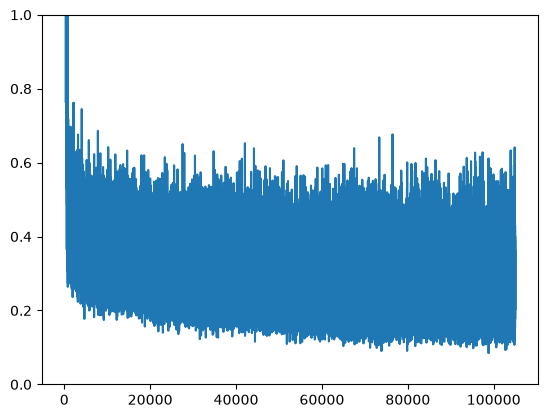

In [9]:
plt.plot(errores)
plt.ylim(0,1)

In [10]:
#Verificación de la red para la predicción
#Proceso de entrenamiento:
pred, real=[],[]
model.eval()
for xi,yi in loader_test:
  y_pred = model(xi.float()).detach().numpy()
  pred+=list(y_pred)
  real+=list(yi.numpy())


NameError: name 'loader_test' is not defined

In [ ]:
for re, pr in zip(real, pred):
  print(re, pr)

Text(0.07142857142857142, 0.9217391304347826, '0.6554445')

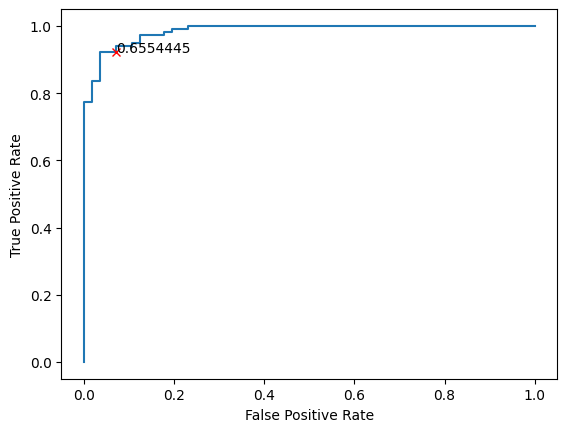

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds=roc_curve([int(r) for r in real], pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
d=(tpr-(1-fpr))**2
#plt.figure()
#plt.plot(d)
i=np.argmin(d)
plt.plot(fpr[i], tpr[i],'xr')
plt.text(fpr[i], tpr[i],str(thresholds[i]))

Otro ejemplo un poco más desarrollado, pero que en el fondo es lo mismo

In [ ]:
!wget 'https://robertohincapie.com/data/archive.zip'
!unzip 'archive.zip'

--2023-08-29 18:24:18--  https://robertohincapie.com/data/archive.zip
Resolving robertohincapie.com (robertohincapie.com)... 190.8.176.107
Connecting to robertohincapie.com (robertohincapie.com)|190.8.176.107|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 491063 (480K) [application/zip]
Saving to: ‘archive.zip’

archive.zip         100%[===================>] 479.55K  3.05MB/s    in 0.2s    

2023-08-29 18:24:18 (3.05 MB/s) - ‘archive.zip’ saved [491063/491063]

Archive:  archive.zip
  inflating: Hotel Reservations.csv  


In [ ]:
import pandas as pd
dataH=pd.read_csv('Hotel Reservations.csv')
dataH=dataH.drop('Booking_ID', axis=1)
#Organización de datos categóricos
#dataH['type_of_meal_plan']=dataH['type_of_meal_plan'].replace({'Meal Plan 1':1, 'Not Selected':0, 'Meal Plan 2':2, 'Meal Plan 3':3})
"""dataH['room_type_reserved']=dataH['room_type_reserved'].replace({'Room_Type 1':1, 'Room_Type 4':4,
                                                                 'Room_Type 2':2, 'Room_Type 6':6,
                                                                 'Room_Type 5':5, 'Room_Type 7':7, 'Room_Type 3':3})
"""
dataH=pd.get_dummies(dataH, prefix_sep='_', columns=['room_type_reserved','type_of_meal_plan','market_segment_type'], drop_first=False)

dataH['booking_status']=dataH['booking_status'].replace({'Not_Canceled':0, 'Canceled':1})

#Ese modelo no converge casi. Voy a quitar los datos que no tienen casi correlación con el estatus
co=dataH.corr()['booking_status']
lst=list(co[(co<0.01) & (co>-0.01)].index)
print(lst)
dataH=dataH.drop(lst, axis=1)
#print(dataH.head())
#Hay poco más de 36000 registros.
X=dataH.drop('booking_status', axis=1).values
Y=dataH['booking_status'].values
print(X.shape, Y.shape)
data=[(xi, yi) for xi, yi in zip(X,Y)]
print(data[0])

['room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'market_segment_type_Aviation']
(36275, 25) (36275,)
(array([2.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 2.240e+02,
       2.017e+03, 1.000e+01, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       6.500e+01, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00]), 0)


In [ ]:
loader = torch.utils.data.DataLoader(data, batch_size=1000, shuffle=True)
#Modelo:
#El modelo debe tener 30 entradas. Una para cada variable
model = torch.nn.Sequential(
    torch.nn.Linear(25, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1),
    torch.nn.Sigmoid(),
    torch.nn.Flatten(0,1)
)
model(torch.unsqueeze(torch.tensor(data[0][0]).float(),0))

tensor([3.0028e-11], grad_fn=<ReshapeAliasBackward0>)

In [ ]:
learning_rate = 1e-5
#Función de error.
loss_fn=torch.nn.BCELoss() #Función adecuada para procesos de clasificación binaria
#Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.5)

In [ ]:
#Proceso de entrenamiento:
errores=[]
for epoch in range(200): #Se realizarán un total de 20 pasadas del data set de entrenamiento
  for xi,yi in loader:
    y_pred = model(xi.float())
    loss = loss_fn(y_pred, yi.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    errores.append(loss.detach().item())
  if(epoch % 1==0):
    #loader_train = torch.utils.data.DataLoader(datos, batch_size=100, shuffle=True)
    print('Epoch: ', epoch, ', Loss: ',loss.item())
    #print(y_pred, yi)

Epoch:  0 , Loss:  0.980534017086029
Epoch:  1 , Loss:  0.7418897151947021
Epoch:  2 , Loss:  0.7442657947540283
Epoch:  3 , Loss:  0.6865530610084534
Epoch:  4 , Loss:  0.6563977003097534
Epoch:  5 , Loss:  0.6198273301124573
Epoch:  6 , Loss:  0.6655370593070984
Epoch:  7 , Loss:  0.589163601398468
Epoch:  8 , Loss:  0.6117615699768066
Epoch:  9 , Loss:  0.6327028870582581
Epoch:  10 , Loss:  0.6071504354476929
Epoch:  11 , Loss:  0.6412177681922913
Epoch:  12 , Loss:  0.5746753215789795
Epoch:  13 , Loss:  0.5652871131896973
Epoch:  14 , Loss:  0.5109779834747314
Epoch:  15 , Loss:  0.6122392416000366
Epoch:  16 , Loss:  0.5854717493057251
Epoch:  17 , Loss:  0.6102122068405151
Epoch:  18 , Loss:  0.6481491327285767
Epoch:  19 , Loss:  0.5836357474327087
Epoch:  20 , Loss:  0.6173669695854187
Epoch:  21 , Loss:  0.5966464877128601
Epoch:  22 , Loss:  0.6246473789215088
Epoch:  23 , Loss:  0.5931522846221924
Epoch:  24 , Loss:  0.5763295888900757
Epoch:  25 , Loss:  0.534641683101654

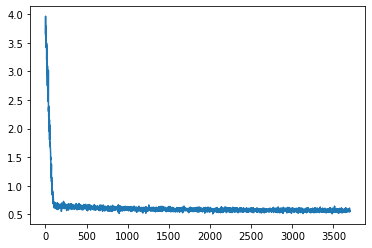

In [ ]:
plt.plot(errores)

In [ ]:
x=[1,2,3,4,5,6]
for i in x:
  print(i)

iterador=iter(x)


1
2
3
4
5
6


In [ ]:
next(iterador)

StopIteration: 